In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats

In [2]:
arabi_genes = pd.read_csv('C:\\Users\\mikep\\git\\Family_level_coexpression\\Data_for_tutorial\\arabi_genes.csv', index_col= 0)
arabi_ortho = pd.read_csv('C:\\Users\\mikep\\git\\Family_level_coexpression\\Data_for_tutorial\\arabi_ortho_trimmed_out_2_gene_families.csv', index_col= 0)
tomato_genes = pd.read_csv('C:\\Users\\mikep\\git\\Family_level_coexpression\\Data_for_tutorial\\tomato_genes.csv', index_col= 0)
tomato_ortho = pd.read_csv('C:\\Users\\mikep\\git\\Family_level_coexpression\\Data_for_tutorial\\tomato_ortho_trimmed_out_2_gene_families.csv', index_col= 0)

In [3]:
log_fc_change_evaluation_value = 1.5
log_fc_change_evaluation_value_negative = -1*log_fc_change_evaluation_value

In [4]:
tomato_ortho

,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj
10772at3193,2450.346409,-0.463596,0.181620,-2.552557,1.069355e-02,1.879411e-02
10950at3193,820.953574,-0.126100,0.192539,-0.654930,5.125128e-01,5.742354e-01
109808at3193,140.364526,-0.455828,0.286738,-1.589702,1.119021e-01,1.547758e-01
109859at3193,46.038966,-1.306142,0.352386,-3.706561,2.100927e-04,5.108887e-04
109997at3193,179.619514,-1.439948,0.259779,-5.542964,2.973933e-08,1.278449e-07
...,...,...,...,...,...,...
9592at3193,499.026848,-0.268884,0.174269,-1.542929,1.228481e-01,1.673168e-01
9601at3193,1031.260474,-1.231811,0.124719,-9.876713,5.252769e-23,1.002314e-21
9609at3193,95.587275,-1.925882,0.403038,-4.778415,1.766826e-06,5.942383e-06
9789at3193,892.098827,1.801654,0.180802,9.964774,2.173680e-23,4.324235e-22


In [5]:
trimmed_tomato_ortho = tomato_ortho.loc[tomato_ortho.index.isin(arabi_ortho.index)]
trimmed_arabi_ortho = arabi_ortho.loc[arabi_ortho.index.isin(trimmed_tomato_ortho.index)]


In [6]:
trimmed_arabi_ortho_named = trimmed_arabi_ortho.rename(columns = {'log2FoldChange':'Arabidopsis Log2FC'})
trimmed_tomato_ortho_named = trimmed_tomato_ortho.rename(columns = {'log2FoldChange':'Tomato Log2FC'})



In [7]:
merged_ortho_df = trimmed_arabi_ortho_named[['Arabidopsis Log2FC']].merge(right = trimmed_tomato_ortho_named, left_index= True, right_index = True)

In [8]:
merged_ortho_df

,Arabidopsis Log2FC,baseMean,Tomato Log2FC,lfcSE,stat,pvalue,padj
Locus,,,,,,,
10950at3193,-0.035878,820.953574,-0.126100,0.192539,-0.654930,5.125128e-01,5.742354e-01
109808at3193,0.929422,140.364526,-0.455828,0.286738,-1.589702,1.119021e-01,1.547758e-01
110108at3193,-0.643508,218.181011,-0.328056,0.190015,-1.726475,8.426192e-02,1.200075e-01
110263at3193,-0.249289,241.984737,0.577213,0.178636,3.231229,1.232592e-03,2.613319e-03
110509at3193,2.383196,132.476352,2.890727,0.605100,4.777275,1.776866e-06,5.965421e-06
...,...,...,...,...,...,...,...
923at3193,0.212197,1489.288291,-0.161708,0.141834,-1.140115,2.542382e-01,3.156876e-01
9592at3193,0.699836,499.026848,-0.268884,0.174269,-1.542929,1.228481e-01,1.673168e-01
9601at3193,-0.204587,1031.260474,-1.231811,0.124719,-9.876713,5.252769e-23,1.002314e-21


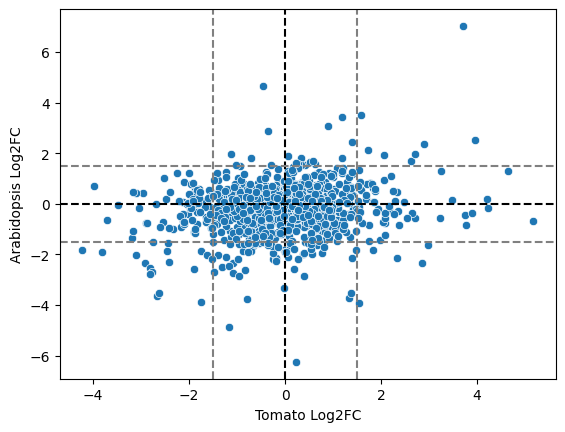

In [9]:
sns.scatterplot(data = merged_ortho_df, x ='Tomato Log2FC', y = 'Arabidopsis Log2FC' )
plt.axvline(0, color="k", linestyle="--")
plt.axhline(0, color="k", linestyle="--")
plt.axvline(1.5, color="grey", linestyle="--")
plt.axhline(1.5, color="grey", linestyle="--")
plt.axvline(-1.5, color="grey", linestyle="--")
plt.axhline(-1.5, color="grey", linestyle="--")

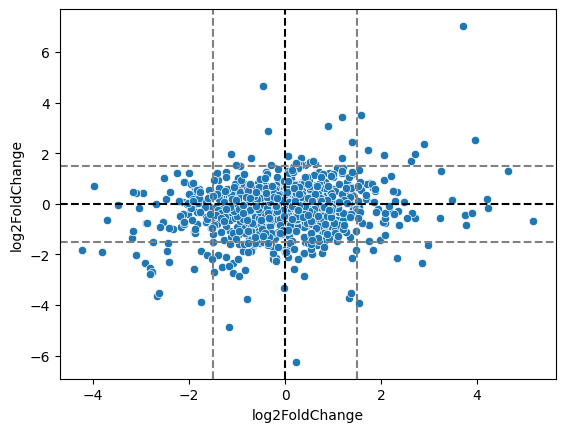

In [10]:
sns.scatterplot(x =trimmed_tomato_ortho['log2FoldChange'], y = trimmed_arabi_ortho['log2FoldChange'], )
plt.axvline(0, color="k", linestyle="--")
plt.axhline(0, color="k", linestyle="--")
plt.axvline(1.5, color="grey", linestyle="--")
plt.axhline(1.5, color="grey", linestyle="--")
plt.axvline(-1.5, color="grey", linestyle="--")
plt.axhline(-1.5, color="grey", linestyle="--")

In [11]:
trimmed_arabi_ortho

,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj
Locus,,,,,,
10950at3193,2117.544930,-0.035878,0.248588,-0.144328,0.885241,0.921175
109808at3193,78.019323,0.929422,0.498435,1.864683,0.062226,0.136547
110108at3193,362.197126,-0.643508,0.507235,-1.268658,0.204563,0.322380
110263at3193,413.266330,-0.249289,0.214669,-1.161271,0.245532,0.371297
110509at3193,1409.050076,2.383196,0.866520,2.750308,0.005954,0.020680
...,...,...,...,...,...,...
923at3193,1084.428909,0.212197,0.154766,1.371085,0.170349,0.284443
9592at3193,575.061761,0.699836,0.196538,3.560812,0.000370,0.001963
9601at3193,366.788308,-0.204587,0.185666,-1.101907,0.270502,0.397667


In [12]:
all(trimmed_arabi_ortho.index == trimmed_tomato_ortho.index)

True

In [13]:
merged_result = pd.DataFrame(data = zip(trimmed_tomato_ortho['log2FoldChange'], trimmed_arabi_ortho['log2FoldChange']), columns = ['Tomato','Arabi'])

all_over_1 = merged_result.loc[(merged_result['Tomato']>log_fc_change_evaluation_value) & (merged_result['Arabi']>log_fc_change_evaluation_value)]
all_under_1 = merged_result.loc[(merged_result['Tomato']<log_fc_change_evaluation_value_negative) & (merged_result['Arabi']<log_fc_change_evaluation_value_negative)]
discord_bottom = merged_result.loc[(merged_result['Tomato']>log_fc_change_evaluation_value) & (merged_result['Arabi']<log_fc_change_evaluation_value_negative)]
discord_top = merged_result.loc[(merged_result['Tomato']<log_fc_change_evaluation_value_negative) & (merged_result['Arabi']>log_fc_change_evaluation_value)]

In [14]:
trimmed_arabi_ortho

,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj
Locus,,,,,,
10950at3193,2117.544930,-0.035878,0.248588,-0.144328,0.885241,0.921175
109808at3193,78.019323,0.929422,0.498435,1.864683,0.062226,0.136547
110108at3193,362.197126,-0.643508,0.507235,-1.268658,0.204563,0.322380
110263at3193,413.266330,-0.249289,0.214669,-1.161271,0.245532,0.371297
110509at3193,1409.050076,2.383196,0.866520,2.750308,0.005954,0.020680
...,...,...,...,...,...,...
923at3193,1084.428909,0.212197,0.154766,1.371085,0.170349,0.284443
9592at3193,575.061761,0.699836,0.196538,3.560812,0.000370,0.001963
9601at3193,366.788308,-0.204587,0.185666,-1.101907,0.270502,0.397667


In [15]:
trimmed_arabi_ortho.loc[trimmed_arabi_ortho['log2FoldChange'] >4]

,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj
Locus,,,,,,
208588at3193,106.815173,4.644706,0.404497,11.482660,1.612424e-30,3.617875e-28
878540at3193,16208.377276,7.031481,0.477371,14.729589,4.162279e-49,2.490430e-46


In [16]:
def get_ncbi_clean_og2gene_for_species(
    species_1, og2genes_only_cococonet, ncbi_mapping
):

    species_1_name = species_1

    first_species_ortho_groups = og2genes_only_cococonet.loc[
        og2genes_only_cococonet["Species"] == species_1
    ]
    shared_orthogroups = first_species_ortho_groups["Orthogroup"].unique()

    list_of_orthogene_pds = []
    for orthogroup in tq.tqdm(
        shared_orthogroups, desc="inner_loop", position=0, leave=False
    ):
        species_1_genes = (
            first_species_ortho_groups["Gene"]
            .loc[first_species_ortho_groups["Orthogroup"] == orthogroup]
            .to_list()
        )
        all_gene_combos = species_1_genes
        current_orthogroup_pd = pd.DataFrame(
            columns=[f"{species_1_name} OrthoGene"], data=all_gene_combos
        )
        current_orthogroup_pd["Orthogroup"] = orthogroup
        list_of_orthogene_pds.append(current_orthogroup_pd)

    final_species_lineup = pd.concat(list_of_orthogene_pds)
    ncbi_added_once = final_species_lineup.merge(
        right=ncbi_mapping[["Orthodb Gene", "Symbol"]],
        right_on="Orthodb Gene",
        left_on=f"{species_1_name} OrthoGene",
    )
    ncbi_added_once_clean = ncbi_added_once.drop(columns="Orthodb Gene")
    return ncbi_added_once_clean

In [17]:
og_groups = pd.read_csv(
    r"C:\Users\mikep\git\Family_level_coexpression\Data_for_tutorial\og_2_Genes_with_ncbi_symbol.csv"
)
og_groups

,Orthogroup,Gene,Species,Ortholevel,Orthodb Gene,Symbol
0,100007at3193,4558_0:003a4f,4558,3193,4558_0:003a4f,LOC110434333
1,100007at3193,4577_0:004254,4577,3193,4577_0:004254,LOC100276500
2,100007at3193,4577_0:004e43,4577,3193,4577_0:004e43,LOC100275058
3,100067at3193,4558_0:00439a,4558,3193,4558_0:00439a,LOC8071983
4,100085at3193,4558_0:002fd8,4558,3193,4558_0:002fd8,LOC8086335
...,...,...,...,...,...,...
502887,9969at3193,15368_0:000e9a,15368,3193,15368_0:000e9a,LOC100834561
502888,99917at3193,39947_0:006297,39947,3193,39947_0:006297,LOC107276177
502889,99917at3193,39947_0:00634f,39947,3193,39947_0:00634f,LOC9269479
502890,99917at3193,39947_0:006629,39947,3193,39947_0:006629,LOC9269626


In [18]:
ncbi_mapping = pd.read_csv(
    r"C:\Users\mikep\git\Family_level_coexpression\Data_for_tutorial\merged_ncbi_to_orthodb_fixed_non_genesymbol.csv"
)

In [19]:
import tqdm as tq
arabi_og = get_ncbi_clean_og2gene_for_species(
    3702, og_groups, ncbi_mapping=ncbi_mapping
)

In [20]:
arabi_og

,3702 OrthoGene,Orthogroup,Symbol
0,3702_0:006584,10009at3193,AT5G42200
1,3702_0:001f5f,10092at3193,AT2G26300
2,3702_0:000e32,10147at3193,AT1G73910
3,3702_0:0018a2,10147at3193,AT1G18450
4,3702_0:000573,10228at3193,AT1G49040
...,...,...,...
25982,3702_0:004152,9877at3193,AT3G58740
25983,3702_0:00114d,9919at3193,AT1G15440
25984,3702_0:002571,9942at3193,AT2G44100
25985,3702_0:003134,9942at3193,AT3G59920


In [21]:
arabi_og.loc[arabi_og['Orthogroup'] == '878562at3193'] ## Discordant bottom right

,3702 OrthoGene,Orthogroup,Symbol
21848,3702_0:0016fb,878562at3193,AT1G77100
21849,3702_0:00230c,878562at3193,AT2G41480
21850,3702_0:004990,878562at3193,AT4G25980
21851,3702_0:0053b1,878562at3193,AT5G64120
21852,3702_0:0056bb,878562at3193,AT5G64100
21853,3702_0:00699d,878562at3193,AT5G39580


In [22]:
arabi_og.loc[arabi_og['Orthogroup'] == '30409at3193']## Discordant top left

,3702 OrthoGene,Orthogroup,Symbol
6412,3702_0:006621,30409at3193,AT5G06740


In [23]:
arabi_og.loc[arabi_og['Orthogroup'] == '122578at3193'] ## Discordant top left

,3702 OrthoGene,Orthogroup,Symbol
1826,3702_0:002bc6,122578at3193,AT2G16060
1827,3702_0:0031f5,122578at3193,AT3G10520


In [24]:
arabi_og.loc[arabi_og['Orthogroup'] == '124591at3193'] ## Gibberilin low

,3702 OrthoGene,Orthogroup,Symbol
2154,3702_0:000523,124591at3193,AT1G44090
2155,3702_0:004443,124591at3193,AT4G25420
2156,3702_0:0067af,124591at3193,AT5G51810


In [25]:
arabi_og.loc[arabi_og['Orthogroup'] == '76646at3193'] ## Etheylene high

,3702 OrthoGene,Orthogroup,Symbol
17622,3702_0:001f05,76646at3193,AT2G47520
17623,3702_0:0037e6,76646at3193,AT3G16770


In [26]:
arabi_og.loc[arabi_og['Orthogroup'] == '74537at3193'] ## bad
arabi_og.loc[arabi_og['Orthogroup'] == '126865at3193'] ## bad
arabi_og.loc[arabi_og['Orthogroup'] == '120630at3193'] ## bad
arabi_og.loc[arabi_og['Orthogroup'] == '880438at3193'] ## Gibberilin breakdown high



,3702 OrthoGene,Orthogroup,Symbol
22356,3702_0:000100,880438at3193,AT1G02400
22357,3702_0:000b61,880438at3193,AT1G78440
22358,3702_0:001339,880438at3193,AT1G47990
22359,3702_0:001a7f,880438at3193,AT1G30040


In [27]:
#arabi_og.loc[arabi_og['Orthogroup'] == '871390at3193']### Bad 27299at3193, 871390at3193 - stomatal genes?
arabi_og.loc[arabi_og['Orthogroup'] == '868372at3193'] ## bad
arabi_og.loc[arabi_og['Orthogroup'] == '178771at3193'] ## Sweet 16/17 - sugar transproters
arabi_og.loc[arabi_og['Orthogroup'] == '424934at3193'] ## Maybe good- changges root lignin during drought?
arabi_og.loc[arabi_og['Orthogroup'] == '84063at3193'] ## Bad
arabi_og.loc[arabi_og['Orthogroup'] == '37749at3193'] ##* more lignin
arabi_og.loc[arabi_og['Orthogroup'] == '125018at3193'] ## bad
arabi_og.loc[arabi_og['Orthogroup'] == '785944at3193'] ## bad
arabi_og.loc[arabi_og['Orthogroup'] == '27299at3193'] ##  bad
arabi_og.loc[arabi_og['Orthogroup'] == '871390at3193'] ## bad
arabi_og.loc[arabi_og['Orthogroup'] == '124591at3193'] ## Gibberilin low





,3702 OrthoGene,Orthogroup,Symbol
2154,3702_0:000523,124591at3193,AT1G44090
2155,3702_0:004443,124591at3193,AT4G25420
2156,3702_0:0067af,124591at3193,AT5G51810


In [28]:
all_over_1

,Tomato,Arabi
4,2.890727,2.383196
43,2.619229,1.695352
130,2.714038,1.955680
271,1.587127,3.496879
349,2.062677,1.928884
724,3.967543,2.508024
757,1.722564,2.129251
822,3.720426,7.031481


In [29]:
merged_result['Classification'] = 'Non-substantial'
merged_result['Classification'].loc[(merged_result['Tomato']>log_fc_change_evaluation_value) & (merged_result['Arabi']>log_fc_change_evaluation_value)] = 'Substantial'
merged_result['Classification'].loc[(merged_result['Tomato']<log_fc_change_evaluation_value_negative) & (merged_result['Arabi']<log_fc_change_evaluation_value_negative)]= 'Substantial'
merged_result['Classification'].loc[(merged_result['Tomato']>log_fc_change_evaluation_value) & (merged_result['Arabi']<log_fc_change_evaluation_value_negative)]= 'Substantial'
merged_result['Classification'].loc[(merged_result['Tomato']<log_fc_change_evaluation_value_negative) & (merged_result['Arabi']>log_fc_change_evaluation_value)]= 'Substantial'

C:\Users\mikep\AppData\Local\Temp\ipykernel_16428\2994845458.py:2: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  merged_result['Classification'].loc[(merged_result['Tomato']>log_fc_change_evaluation_value) & (merged_result['Arabi']>log_fc_ch

Text(0, 0.5, 'Orthogroup-wise log2-fold change in Arabidopsis')

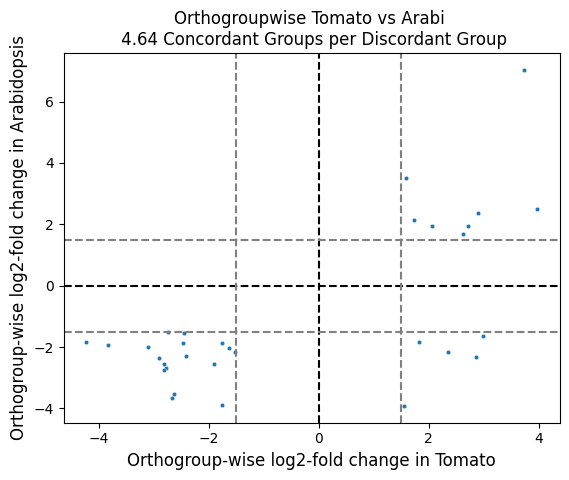

In [30]:
sns.scatterplot(data = merged_result.loc[merged_result['Classification'] == "Substantial"] , x ='Tomato', y = 'Arabi', s = 10)
plt.axvline(0, color="k", linestyle="--")
plt.axhline(0, color="k", linestyle="--")
plt.axvline(1.5, color="grey", linestyle="--")
plt.axhline(1.5, color="grey", linestyle="--")
plt.axvline(-1.5, color="grey", linestyle="--")
plt.axhline(-1.5, color="grey", linestyle="--")
plt.title('Orthogroupwise Tomato vs Arabi \n 4.64 Concordant Groups per Discordant Group')
plt.xlabel("Orthogroup-wise log2-fold change in Tomato", fontsize = 12)
plt.ylabel("Orthogroup-wise log2-fold change in Arabidopsis", fontsize = 12)

In [31]:
discord_ratio = (len(all_over_1)+len(all_under_1))/(len(discord_bottom)+len(discord_top))
discord_ratio

5.2

In [32]:
discord_bottom

,Tomato,Arabi
195,2.980530,-1.631123
327,2.858399,-2.330700
403,1.542266,-3.918989
633,1.827832,-1.839793
894,2.345474,-2.152746


In [33]:
discord_top

,Tomato,Arabi


In [34]:
merged_result = pd.DataFrame(data = zip(trimmed_tomato_ortho['log2FoldChange'], trimmed_arabi_ortho['log2FoldChange']), columns = ['Tomato','Arabi'])
pos_thresh = 1
neg_thresh = 1
tomato_any_change = merged_result.loc[(merged_result['Tomato']>pos_thresh)|(merged_result['Tomato']<neg_thresh)]
tomato_concordant_change = merged_result.loc[((merged_result['Tomato']>pos_thresh) & (merged_result['Arabi']>pos_thresh)) | ((merged_result['Tomato']<neg_thresh) & (merged_result['Arabi']<neg_thresh))]
tomato_disconcordant_change = merged_result.loc[((merged_result['Tomato']>pos_thresh) & (merged_result['Arabi']<neg_thresh)) | ((merged_result['Tomato']<neg_thresh) & (merged_result['Arabi']>pos_thresh))]
percent_concordant_tomato = len(tomato_concordant_change)/len(tomato_any_change)
percent_non_discord_tomato = len(tomato_concordant_change)/(len(tomato_concordant_change+tomato_disconcordant_change))
print(percent_concordant_tomato)
print(percent_non_discord_tomato)


arabi_any_change = merged_result.loc[(merged_result['Arabi']>pos_thresh)|(merged_result['Arabi']<neg_thresh)]
arabi_concordant_change = merged_result.loc[((merged_result['Arabi']>pos_thresh) & (merged_result['Tomato']>pos_thresh)) | ((merged_result['Arabi']<neg_thresh) & (merged_result['Tomato']<neg_thresh))]
arabi_disconcordant_change = merged_result.loc[((merged_result['Arabi']>pos_thresh) & (merged_result['Tomato']<neg_thresh)) | ((merged_result['Arabi']<neg_thresh) & (merged_result['Tomato']>pos_thresh))]

percent_concordant_arabi = len(arabi_concordant_change)/len(arabi_any_change)
percent_non_discord_arabi = len(arabi_concordant_change)/(len(arabi_concordant_change+arabi_disconcordant_change))

print(percent_concordant_arabi)
print(percent_non_discord_arabi)

0.8437190900098912
0.8437190900098912
0.8437190900098912
0.8437190900098912


In [35]:
arabi_disconcordant_change

,Tomato,Arabi
9,0.169207,1.460630
11,-0.152169,1.011413
12,2.344046,0.485305
13,2.371027,-0.818157
21,1.423373,0.354012
...,...,...
968,1.360949,-0.522322
969,-0.862964,1.195038
974,0.141571,1.326745
981,1.367171,-3.509446


In [36]:
tomato_any_change

,Tomato,Arabi
0,-0.126100,-0.035878
1,-0.455828,0.929422
2,-0.328056,-0.643508
3,0.577213,-0.249289
4,2.890727,2.383196
...,...,...
1006,-0.161708,0.212197
1007,-0.268884,0.699836
1008,-1.231811,-0.204587
1009,-1.925882,0.104964


In [37]:
tomato_concordant_change

,Tomato,Arabi
0,-0.126100,-0.035878
1,-0.455828,0.929422
2,-0.328056,-0.643508
3,0.577213,-0.249289
4,2.890727,2.383196
...,...,...
1006,-0.161708,0.212197
1007,-0.268884,0.699836
1008,-1.231811,-0.204587
1009,-1.925882,0.104964


In [38]:
arabidopsis_tomato_nm = pd.read_csv(r'C:\Users\mikep\git\Family_level_coexpression\Data_for_tutorial\tomato_to_arabidopsis_ortholog_NM.csv')

In [39]:
arabidopsis_tomato_nm = arabidopsis_tomato_nm.drop_duplicates(subset = 'arabidopsis Symbol',)
arabidopsis_tomato_nm = arabidopsis_tomato_nm.drop_duplicates(subset = 'tomato Symbol',)
arabidopsis_tomato_nm

,tomato OrthoGene,arabidopsis OrthoGene,Orthogroup,tomato Symbol,arabidopsis Symbol
0,4081_0:002534,3702_0:006584,10009at3193,LOC101245541,AT5G42200
2,4081_0:0044e5,3702_0:001f5f,10092at3193,GLYMA_04G056600,AT2G26300
3,4081_0:0060db,3702_0:000e32,10147at3193,LOC101260909,AT1G73910
5,4081_0:001ce5,3702_0:000573,10228at3193,LOC101262196,AT1G49040
6,4081_0:00485f,3702_0:0012bf,10238at3193,LOC101260971,AT1G79120
...,...,...,...,...,...
53411,4081_0:001e35,3702_0:00121f,9828at3193,LOC101268561,AT1G74750
53413,4081_0:00467b,3702_0:0052b3,9836at3193,LOC101260957,AT5G11380
53414,4081_0:003e73,3702_0:001def,9877at3193,LOC101258079,AT2G42790
53420,4081_0:00201e,3702_0:00114d,9919at3193,LOC101252265,AT1G15440


In [40]:
arabi_genes_trimmed = arabi_genes.merge(how = 'inner', left_index= True, right = arabidopsis_tomato_nm[['tomato Symbol','arabidopsis Symbol']], right_on= 'arabidopsis Symbol')
arabi_genes_trimmed = arabi_genes_trimmed.drop_duplicates(subset = 'tomato Symbol', keep = False)
arabi_genes_trimmed

,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj,tomato Symbol,arabidopsis Symbol
38398,279.396501,0.829771,0.279715,2.966485,3.012254e-03,1.133821e-02,LOC101253248,AT1G01020
37840,1560.891356,-0.150399,0.209296,-0.718593,4.723916e-01,6.125629e-01,AT1G01040,AT1G01040
36328,1068.595456,-0.225000,0.158336,-1.421025,1.553096e-01,2.712849e-01,LOC101264169,AT1G01050
44489,459.968316,-4.223427,0.429071,-9.843190,7.334749e-23,9.657051e-21,LOC101261662,AT1G01060
36675,1186.453103,-1.414881,0.296388,-4.773745,1.808312e-06,1.958277e-05,LOC101256355,AT1G01090
...,...,...,...,...,...,...,...,...
51889,156.922459,-1.503203,0.475221,-3.163169,1.560615e-03,6.573955e-03,LOC101253642,AT5G67350
17282,1544.917312,0.097392,0.256552,0.379618,7.042288e-01,8.036424e-01,LOC101254550,AT5G67370
34629,185.116966,-0.513197,0.321462,-1.596448,1.103887e-01,2.082768e-01,LOC101256933,AT5G67390
18490,575.977171,0.409064,0.213761,1.913656,5.566413e-02,1.221778e-01,LOC101253364,AT5G67490


In [41]:
tomato_genes_trimmed = tomato_genes.merge(how = 'inner', left_index= True, right = arabidopsis_tomato_nm[['tomato Symbol','arabidopsis Symbol']], right_on= 'tomato Symbol')
tomato_genes_trimmed = tomato_genes_trimmed.drop_duplicates(subset = 'arabidopsis Symbol', keep = False)
tomato_genes_trimmed

,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj,tomato Symbol,arabidopsis Symbol
14614,1208.572522,-2.600665,0.154842,-16.795579,2.629260e-63,2.273878e-61,LOC101263636,AT1G14630
50585,534.934240,0.562814,0.183441,3.068088,2.154335e-03,4.103930e-03,sos1,AT2G01980
5373,459.542536,1.640208,0.187352,8.754689,2.046666e-18,1.955479e-17,LOC101263144,AT4G32250
34530,31.274656,-0.924410,0.505198,-1.829800,6.727989e-02,9.642596e-02,LOC101262550,AT1G68130
10005,394.729439,0.257145,0.187296,1.372936,1.697723e-01,2.210316e-01,LOC101261647,AT1G68080
...,...,...,...,...,...,...,...,...
22924,333.489666,-0.488295,0.216593,-2.254434,2.416890e-02,3.796822e-02,LOC101258845,AT5G10310
44592,185.535676,-2.216221,0.254426,-8.710660,3.021110e-18,2.848099e-17,LOC101264200,AT5G64700
7494,92.567027,1.392738,0.295681,4.710266,2.473941e-06,7.239471e-06,LOC101255080,AT2G28060
47950,261.883098,-0.569755,0.279886,-2.035664,4.178410e-02,6.267444e-02,LOC101245935,AT1G26180


In [42]:
tomato_genes_trimmed

,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj,tomato Symbol,arabidopsis Symbol
14614,1208.572522,-2.600665,0.154842,-16.795579,2.629260e-63,2.273878e-61,LOC101263636,AT1G14630
50585,534.934240,0.562814,0.183441,3.068088,2.154335e-03,4.103930e-03,sos1,AT2G01980
5373,459.542536,1.640208,0.187352,8.754689,2.046666e-18,1.955479e-17,LOC101263144,AT4G32250
34530,31.274656,-0.924410,0.505198,-1.829800,6.727989e-02,9.642596e-02,LOC101262550,AT1G68130
10005,394.729439,0.257145,0.187296,1.372936,1.697723e-01,2.210316e-01,LOC101261647,AT1G68080
...,...,...,...,...,...,...,...,...
22924,333.489666,-0.488295,0.216593,-2.254434,2.416890e-02,3.796822e-02,LOC101258845,AT5G10310
44592,185.535676,-2.216221,0.254426,-8.710660,3.021110e-18,2.848099e-17,LOC101264200,AT5G64700
7494,92.567027,1.392738,0.295681,4.710266,2.473941e-06,7.239471e-06,LOC101255080,AT2G28060
47950,261.883098,-0.569755,0.279886,-2.035664,4.178410e-02,6.267444e-02,LOC101245935,AT1G26180


In [43]:
arabi_genes_trimmed = arabi_genes_trimmed.loc[arabi_genes_trimmed['arabidopsis Symbol'].isin(tomato_genes_trimmed['arabidopsis Symbol'])]
tomato_genes_trimmed = tomato_genes_trimmed.loc[tomato_genes_trimmed['tomato Symbol'].isin(arabi_genes_trimmed['tomato Symbol'])]


In [44]:
tomato_genes_trimmed

,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj,tomato Symbol,arabidopsis Symbol
50585,534.934240,0.562814,0.183441,3.068088,2.154335e-03,4.103930e-03,sos1,AT2G01980
5373,459.542536,1.640208,0.187352,8.754689,2.046666e-18,1.955479e-17,LOC101263144,AT4G32250
34530,31.274656,-0.924410,0.505198,-1.829800,6.727989e-02,9.642596e-02,LOC101262550,AT1G68130
10005,394.729439,0.257145,0.187296,1.372936,1.697723e-01,2.210316e-01,LOC101261647,AT1G68080
43753,218.854301,-0.934817,0.226668,-4.124171,3.720722e-05,9.293481e-05,LOC101261146,AT1G48140
...,...,...,...,...,...,...,...,...
25364,503.274810,-0.067034,0.158118,-0.423951,6.716014e-01,7.236105e-01,LOC101245535,AT3G29090
22924,333.489666,-0.488295,0.216593,-2.254434,2.416890e-02,3.796822e-02,LOC101258845,AT5G10310
44592,185.535676,-2.216221,0.254426,-8.710660,3.021110e-18,2.848099e-17,LOC101264200,AT5G64700
7494,92.567027,1.392738,0.295681,4.710266,2.473941e-06,7.239471e-06,LOC101255080,AT2G28060


In [45]:
tomato_genes_trimmed = (tomato_genes_trimmed.set_index('arabidopsis Symbol')
          .reindex(arabi_genes_trimmed.set_index('arabidopsis Symbol').index)
          .reset_index()
       )

In [46]:
tomato_genes_trimmed

,arabidopsis Symbol,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj,tomato Symbol
0,AT1G01020,82.574035,1.556570,0.365328,4.260743,2.037482e-05,5.291478e-05,LOC101253248
1,AT1G01050,285.363345,-1.243455,0.301339,-4.126431,3.684369e-05,9.211423e-05,LOC101264169
2,AT1G01060,22697.287287,-5.534877,0.149593,-36.999607,1.161880e-299,2.140298e-295,LOC101261662
3,AT1G01090,2198.213499,0.275947,0.204560,1.348978,1.773441e-01,2.296398e-01,LOC101256355
4,AT1G01100,5422.194905,0.139494,0.165498,0.842876,3.992981e-01,4.661852e-01,LOC101249479
...,...,...,...,...,...,...,...,...
7681,AT5G67350,170.326147,-0.287900,0.257562,-1.117789,2.636569e-01,3.258940e-01,LOC101253642
7682,AT5G67370,6163.433566,-2.352309,0.152159,-15.459526,6.507602e-54,4.036247e-52,LOC101254550
7683,AT5G67390,469.889788,2.554874,0.351618,7.266060,3.701229e-13,2.266634e-12,LOC101256933
7684,AT5G67490,159.596825,-0.311219,0.245848,-1.265900,2.055489e-01,2.619270e-01,LOC101253364


In [47]:
arabi_genes_trimmed = arabi_genes_trimmed.reset_index()

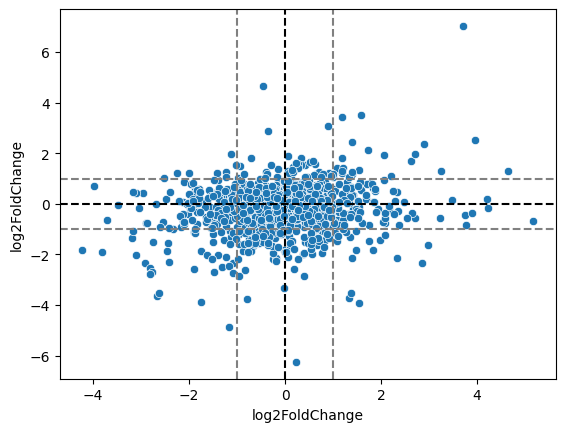

In [48]:
sns.scatterplot(x =trimmed_tomato_ortho['log2FoldChange'], y = trimmed_arabi_ortho['log2FoldChange'], )
plt.axvline(0, color="k", linestyle="--")
plt.axhline(0, color="k", linestyle="--")
plt.axvline(1, color="grey", linestyle="--")
plt.axhline(1, color="grey", linestyle="--")
plt.axvline(-1, color="grey", linestyle="--")
plt.axhline(-1, color="grey", linestyle="--")

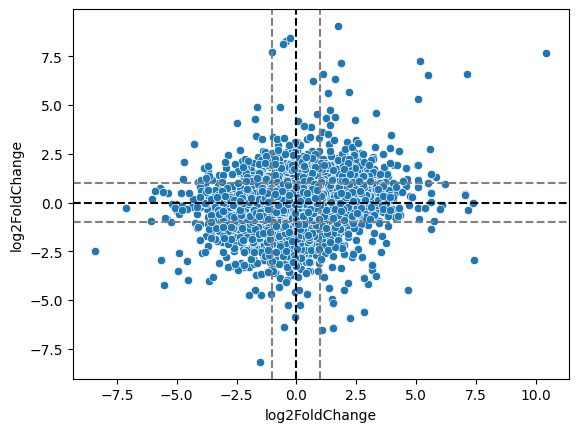

In [49]:
sns.scatterplot(x =tomato_genes_trimmed['log2FoldChange'], y = arabi_genes_trimmed['log2FoldChange'])
plt.axvline(0, color="k", linestyle="--")
plt.axhline(0, color="k", linestyle="--")
plt.axvline(1, color="grey", linestyle="--")
plt.axhline(1, color="grey", linestyle="--")
plt.axvline(-1, color="grey", linestyle="--")
plt.axhline(-1, color="grey", linestyle="--")

In [50]:
log_fc_change_evaluation_value = 1.5
log_fc_change_evaluation_value_negative = -1*log_fc_change_evaluation_value

In [51]:
new_merged_result = pd.DataFrame(data = zip(tomato_genes_trimmed['log2FoldChange'], arabi_genes_trimmed['log2FoldChange']), columns = ['Tomato','Arabi'])

all_over_1 = new_merged_result.loc[(new_merged_result['Tomato']>log_fc_change_evaluation_value) & (new_merged_result['Arabi']>log_fc_change_evaluation_value)]
all_under_1 = new_merged_result.loc[(new_merged_result['Tomato']<log_fc_change_evaluation_value_negative) & (new_merged_result['Arabi']<log_fc_change_evaluation_value_negative)]
discord_bottom = new_merged_result.loc[(new_merged_result['Tomato']>log_fc_change_evaluation_value) & (new_merged_result['Arabi']<log_fc_change_evaluation_value_negative)]
discord_top = new_merged_result.loc[(new_merged_result['Tomato']<log_fc_change_evaluation_value_negative) & (new_merged_result['Arabi']>log_fc_change_evaluation_value)]

In [52]:
new_merged_result['Classification'] = 'Non-substantial'
new_merged_result['Classification'].loc[(new_merged_result['Tomato']>log_fc_change_evaluation_value) & (new_merged_result['Arabi']>log_fc_change_evaluation_value)] = 'Substantial'
new_merged_result['Classification'].loc[(new_merged_result['Tomato']<log_fc_change_evaluation_value_negative) & (new_merged_result['Arabi']<log_fc_change_evaluation_value_negative)]= 'Substantial'
new_merged_result['Classification'].loc[(new_merged_result['Tomato']>log_fc_change_evaluation_value) & (new_merged_result['Arabi']<log_fc_change_evaluation_value_negative)]= 'Substantial'
new_merged_result['Classification'].loc[(new_merged_result['Tomato']<log_fc_change_evaluation_value_negative) & (new_merged_result['Arabi']>log_fc_change_evaluation_value)]= 'Substantial'

C:\Users\mikep\AppData\Local\Temp\ipykernel_16428\1856289886.py:2: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  new_merged_result['Classification'].loc[(new_merged_result['Tomato']>log_fc_change_evaluation_value) & (new_merged_result['Arabi

Text(0.5, 0, 'Genewise log2-fold change in Tomato')

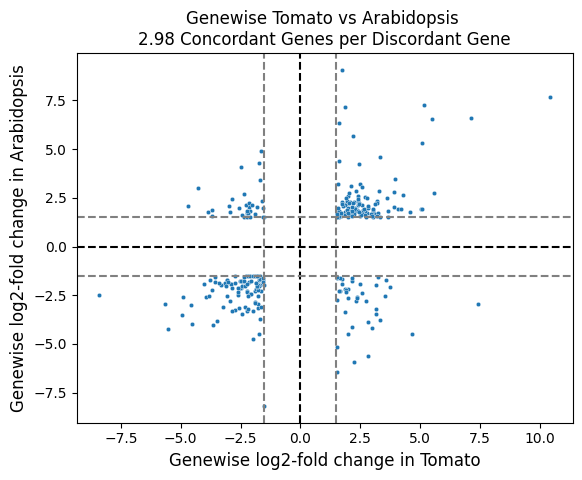

In [53]:
sns.scatterplot(data = new_merged_result.loc[new_merged_result['Classification'] == "Substantial"] , x ='Tomato', y = 'Arabi', s = 10 )
plt.axvline(0, color="k", linestyle="--")
plt.axhline(0, color="k", linestyle="--")
plt.axvline(1.5, color="grey", linestyle="--")
plt.axhline(1.5, color="grey", linestyle="--")
plt.axvline(-1.5, color="grey", linestyle="--")
plt.axhline(-1.5, color="grey", linestyle="--")
plt.title('Genewise Tomato vs Arabidopsis \n2.98 Concordant Genes per Discordant Gene')
plt.ylabel("Genewise log2-fold change in Arabidopsis", fontsize = 12)
plt.xlabel("Genewise log2-fold change in Tomato", fontsize = 12)

In [54]:
discord_ratio = (len(all_over_1)+len(all_under_1))/(len(discord_bottom)+len(discord_top))
discord_ratio

2.986111111111111

In [55]:
all_over_1

,Tomato,Arabi
47,1.694244,1.632967
69,2.077465,2.273296
71,1.525909,1.796257
119,2.699202,2.522209
190,3.016998,1.870981
...,...,...
7191,2.202253,2.247793
7417,2.170963,2.050459
7487,2.556232,3.028377
7555,4.565852,1.792600


In [56]:
all_under_1

,Tomato,Arabi
2,-5.534877,-4.223427
6,-3.956204,-2.580977
110,-2.273082,-1.524271
305,-1.669527,-1.500678
329,-2.180735,-1.508444
...,...,...
7147,-2.299991,-2.026645
7330,-1.553070,-1.636608
7383,-2.556446,-3.172595
7473,-1.864202,-1.850647


In [57]:
merged_result

,Tomato,Arabi
0,-0.126100,-0.035878
1,-0.455828,0.929422
2,-0.328056,-0.643508
3,0.577213,-0.249289
4,2.890727,2.383196
...,...,...
1006,-0.161708,0.212197
1007,-0.268884,0.699836
1008,-1.231811,-0.204587
1009,-1.925882,0.104964


In [58]:
merged_result = pd.DataFrame(data = zip(tomato_genes_trimmed['log2FoldChange'], arabi_genes_trimmed['log2FoldChange']), columns = ['Tomato','Arabi'])

pos_thresh = 0
neg_thresh = 0
tomato_any_change = merged_result.loc[(merged_result['Tomato']>pos_thresh)|(merged_result['Tomato']<neg_thresh)]
tomato_concordant_change = merged_result.loc[((merged_result['Tomato']>pos_thresh) & (merged_result['Arabi']>pos_thresh)) | ((merged_result['Tomato']<neg_thresh) & (merged_result['Arabi']<neg_thresh))]
tomato_disconcordant_change = merged_result.loc[((merged_result['Tomato']>pos_thresh) & (merged_result['Arabi']<neg_thresh)) | ((merged_result['Tomato']<neg_thresh) & (merged_result['Arabi']>pos_thresh))]
percent_concordant_tomato = len(tomato_concordant_change)/len(tomato_any_change)
percent_non_discord_tomato = len(tomato_concordant_change)/(len(tomato_concordant_change+tomato_disconcordant_change))
print(percent_concordant_tomato)
print(percent_non_discord_tomato)


arabi_any_change = merged_result.loc[(merged_result['Arabi']>pos_thresh)|(merged_result['Arabi']<neg_thresh)]
arabi_concordant_change = merged_result.loc[((merged_result['Arabi']>pos_thresh) & (merged_result['Tomato']>pos_thresh)) | ((merged_result['Arabi']<neg_thresh) & (merged_result['Tomato']<neg_thresh))]
arabi_disconcordant_change = merged_result.loc[((merged_result['Arabi']>pos_thresh) & (merged_result['Tomato']<neg_thresh)) | ((merged_result['Arabi']<neg_thresh) & (merged_result['Tomato']>pos_thresh))]

percent_concordant_arabi = len(arabi_concordant_change)/len(arabi_any_change)
percent_non_discord_arabi = len(arabi_concordant_change)/(len(arabi_concordant_change+arabi_disconcordant_change))

print(percent_concordant_arabi)
print(percent_non_discord_arabi)

0.544496487119438
0.544496487119438
0.544496487119438
0.544496487119438


In [59]:
stats.spearmanr(a=tomato_genes_trimmed['log2FoldChange'], b = arabi_genes_trimmed['log2FoldChange'] )

SignificanceResult(statistic=np.float64(0.1691970345753542), pvalue=np.float64(1.840213982841898e-50))

In [60]:
down = tomato_genes_trimmed[
    (tomato_genes_trimmed["log2FoldChange"] <= -2) & (tomato_genes_trimmed["padj"] <= 0.001)
]
up = tomato_genes_trimmed[
    (tomato_genes_trimmed["log2FoldChange"] >= 2) & (tomato_genes_trimmed["padj"] <= 0.001)
]
down_arabi = arabi_genes_trimmed[
    (arabi_genes_trimmed["log2FoldChange"] <= -2)
    & (arabi_genes_trimmed["padj"] <= 0.001)
]
up_arabi = arabi_genes_trimmed[
    (arabi_genes_trimmed["log2FoldChange"] >= 2) & (arabi_genes_trimmed["padj"] <= 0.001)
]

In [61]:
down_arabi_ortho = trimmed_arabi_ortho[
    (trimmed_arabi_ortho["log2FoldChange"] <= -2)
    & (trimmed_arabi_ortho["padj"] <= 0.001)
]
up_arabi_ortho = trimmed_arabi_ortho[
    (trimmed_arabi_ortho["log2FoldChange"] >= 2) & (trimmed_arabi_ortho["padj"] <= 0.001)]

down_ortho = trimmed_tomato_ortho[
    (trimmed_tomato_ortho["log2FoldChange"] <= -2) & (trimmed_tomato_ortho["padj"] <= 0.001)
]
up_ortho = trimmed_tomato_ortho[
    (trimmed_tomato_ortho["log2FoldChange"] >= 2) & (trimmed_tomato_ortho["padj"] <= 0.001)
]

In [62]:
len(up_arabi_ortho.merge(how = "inner", right_index = True, left_index= True, right = up_ortho))

2

In [63]:
up_ortho

,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj
110509at3193,132.476352,2.890727,0.605100,4.777275,1.776866e-06,5.965421e-06
111504at3193,1503.423395,2.344046,0.206103,11.373184,5.687460e-30,1.899206e-28
11159at3193,44.435868,2.371027,0.383288,6.186017,6.170343e-10,3.315673e-09
115008at3193,56.389943,2.619229,0.344530,7.602320,2.908679e-14,2.461663e-13
115760at3193,98.223490,3.749960,0.535450,7.003378,2.498639e-12,1.699075e-11
118328at3193,263.725774,2.083624,0.219141,9.508123,1.941334e-21,3.241335e-20
119308at3193,187.994258,2.710986,0.219048,12.376203,3.515879e-35,1.730183e-33
121314at3193,7628.171970,4.651262,0.161171,28.859091,3.896607e-183,7.286655e-180
124034at3193,701.019634,2.062288,0.232199,8.881546,6.593759e-19,8.807378e-18
126046at3193,3477.232995,2.714038,0.232177,11.689501,1.442315e-31,5.619019e-30


In [64]:
up_arabi_ortho

,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj
Locus,,,,,,
208588at3193,106.815173,4.644706,0.404497,11.482660,1.612424e-30,3.617875e-28
22623at3193,23.769135,3.496879,0.684122,5.111485,3.196358e-07,3.956871e-06
429539at3193,416.401939,3.091847,0.319931,9.664120,4.282839e-22,4.046156e-20
590611at3193,640.478295,2.859653,0.459679,6.220976,4.940715e-10,1.136998e-08
791305at3193,6076.740017,3.423728,0.225602,15.175962,5.102387e-52,4.579392e-49
871290at3193,1042.034686,2.508024,0.269307,9.312866,1.244285e-20,1.063568e-18
873829at3193,4668.161391,2.129251,0.188639,11.287444,1.513748e-29,2.717177e-27
878540at3193,16208.377276,7.031481,0.477371,14.729589,4.162279e-49,2.490430e-46


In [65]:
up

,arabidopsis Symbol,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj,tomato Symbol
13,AT1G01240,773.081084,3.520915,0.253350,13.897441,6.564710e-44,2.675410e-42,LOC101256522
15,AT1G01290,30.686129,3.373121,0.548537,6.149301,7.782526e-10,3.477970e-09,LOC101247025
16,AT1G01300,395.276457,3.521809,0.215713,16.326350,6.410655e-60,5.025135e-58,LOC101254425
69,AT1G02300,1966.547707,2.077465,0.166248,12.496210,7.829576e-36,2.127266e-34,LOC101251744
93,AT1G02960,32.808280,3.367007,0.571278,5.893813,3.773834e-09,1.559744e-08,LOC101258897
...,...,...,...,...,...,...,...,...
7651,AT5G66030,700.040727,2.350113,0.184598,12.730958,3.979269e-37,1.152549e-35,LOC101254258
7652,AT5G66050,688.180123,4.720131,0.313008,15.079905,2.195843e-51,1.229472e-49,LOC101247280
7664,AT5G66540,272.875924,2.031807,0.289682,7.013925,2.317239e-12,1.329363e-11,LOC101253879
7665,AT5G66590,579.079400,2.223749,0.307813,7.224353,5.034947e-13,3.052308e-12,LOC101257731


In [66]:
up_arabi

,index,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj,tomato Symbol,arabidopsis Symbol
69,37410,1704.703924,2.273296,0.226605,10.031959,1.103058e-23,1.623164e-21,LOC101251744,AT1G02300
100,46632,244.041301,4.909129,0.676055,7.261436,3.830035e-13,1.623916e-11,LOC101256498,AT1G03070
119,14336,231.147693,2.522209,0.449622,5.609616,2.027762e-08,3.529637e-07,LOC101267058,AT1G03360
126,52742,272.881762,4.077672,0.438625,9.296489,1.451593e-20,1.559438e-18,LOC101244780,AT1G03470
177,38408,427.962919,2.323308,0.354202,6.559274,5.407028e-11,1.564999e-09,LOC101248918,AT1G04620
...,...,...,...,...,...,...,...,...,...
7453,51095,352.905914,2.092255,0.297903,7.023265,2.167433e-12,8.127177e-11,LOC101266226,AT5G58370
7487,43879,431.894437,3.028377,0.377604,8.019988,1.057555e-15,6.475122e-14,LOC101265201,AT5G60040
7508,28383,1486.612708,2.066535,0.256095,8.069418,7.063405e-16,4.465245e-14,LOC101259425,AT5G61380
7528,16939,43.017272,2.709623,0.500485,5.413991,6.163523e-08,9.602265e-07,LOC101265213,AT5G62370


In [67]:
up_arabi.merge(how = "inner", on = 'arabidopsis Symbol', right = up)

,index,baseMean_x,log2FoldChange_x,lfcSE_x,stat_x,pvalue_x,padj_x,tomato Symbol_x,arabidopsis Symbol,baseMean_y,log2FoldChange_y,lfcSE_y,stat_y,pvalue_y,padj_y,tomato Symbol_y
0,37410,1704.703924,2.273296,0.226605,10.031959,1.103058e-23,1.623164e-21,LOC101251744,AT1G02300,1966.547707,2.077465,0.166248,12.496210,7.829576e-36,2.127266e-34,LOC101251744
1,14336,231.147693,2.522209,0.449622,5.609616,2.027762e-08,3.529637e-07,LOC101267058,AT1G03360,85.080935,2.699202,0.411189,6.564390,5.224628e-11,2.619566e-10,LOC101267058
2,36089,401.994829,3.122644,0.242442,12.879967,5.836084e-38,2.322629e-35,LOC101255183,AT1G15510,120.618031,2.120185,0.341672,6.205326,5.458366e-10,2.485135e-09,LOC101255183
3,28990,1760.048535,4.254156,0.291552,14.591391,3.186328e-48,2.936621e-45,LOC101255185,AT1G16030,18443.123120,2.455365,0.650977,3.771815,1.620643e-04,3.705332e-04,LOC101255185
4,254,2471.881822,2.312580,0.490882,4.711073,2.464156e-06,2.566915e-05,LOC101258429,AT1G28330,5326.247786,3.191949,0.300080,10.636989,2.005040e-26,3.162229e-25,LOC101258429
5,51541,69.046406,2.340967,0.540501,4.331110,1.483596e-05,1.217397e-04,LOC101257826,AT1G30960,203.148052,2.427976,0.240163,10.109688,5.004351e-24,6.788302e-23,LOC101257826
6,7853,316.908410,2.510030,0.251559,9.977910,1.904357e-23,2.733377e-21,LOC101244367,AT1G48460,119.503515,2.786809,0.383479,7.267182,3.670655e-13,2.248657e-12,LOC101244367
7,42732,1164.064943,2.794628,0.526201,5.310950,1.090554e-07,1.591390e-06,LOC101256536,AT1G59860,627.619958,3.931761,1.058001,3.716215,2.022296e-04,4.556350e-04,LOC101256536
8,3026,175.944756,6.525599,0.631996,10.325375,5.410687e-25,8.772828e-23,LOC101256908,AT1G68050,636.987165,5.521131,0.434430,12.708905,5.276819e-37,1.509383e-35,LOC101256908
9,36538,64.288553,2.746667,0.456799,6.012862,1.822759e-09,3.935676e-08,LOC101262206,AT1G68930,46.801826,5.570382,0.752398,7.403507,1.326338e-13,8.560779e-13,LOC101262206


In [68]:
from sklearn.metrics import roc_curve


def calculate_threshold_exceedance_auroc(source_log2fc, target_log2fc, evaluation_threshold):
    paired_values = pd.DataFrame(
        {
            "source_log2fc": source_log2fc,
            "target_log2fc": target_log2fc,
        }
    ).dropna()

    substantial_pair_mask = (
        paired_values["source_log2fc"].abs() >= evaluation_threshold
    ) & (paired_values["target_log2fc"].abs() >= evaluation_threshold)
    paired_values = paired_values.loc[substantial_pair_mask].copy()

    paired_values = paired_values.loc[
        paired_values["source_log2fc"] * paired_values["target_log2fc"] != 0
    ].copy()
    paired_values["pair_class"] = "discordant"
    paired_values.loc[
        paired_values["source_log2fc"] * paired_values["target_log2fc"] > 0,
        "pair_class",
    ] = "concordant"

    target_positive_direction = paired_values["target_log2fc"] >= evaluation_threshold
    n_concordant = int((paired_values["pair_class"] == "concordant").sum())
    n_discordant = int((paired_values["pair_class"] == "discordant").sum())

    if target_positive_direction.nunique() < 2:
        return {
            "summary": {
                "auroc": float("nan"),
                "n_pairs": len(paired_values),
                "n_target_positive": int(target_positive_direction.sum()),
                "n_target_negative": int((~target_positive_direction).sum()),
                "n_concordant": n_concordant,
                "n_discordant": n_discordant,
            },
            "roc_curve": pd.DataFrame({"fpr": [0.0, 1.0], "tpr": [0.0, 1.0]}),
        }

    source_score_ranks = stats.rankdata(paired_values["source_log2fc"] )
    n_positive = int(target_positive_direction.sum())
    n_negative = int((~target_positive_direction).sum())
    positive_rank_sum = source_score_ranks[target_positive_direction.to_numpy()].sum()
    auroc = (
        positive_rank_sum - (n_positive * (n_positive + 1) / 2)
    ) / (n_positive * n_negative)
    fpr, tpr, _ = roc_curve(
        target_positive_direction.astype(int), paired_values["source_log2fc"]
    )

    return {
        "summary": {
            "auroc": auroc,
            "n_pairs": len(paired_values),
            "n_target_positive": n_positive,
            "n_target_negative": n_negative,
            "n_concordant": n_concordant,
            "n_discordant": n_discordant,
        },
        "roc_curve": pd.DataFrame({"fpr": fpr, "tpr": tpr}),
    }


def summarize_bidirectional_threshold_aurocs(
    paired_log2fc_df, left_species_label, right_species_label, evaluation_threshold, pair_type
    ):
    left_to_right = calculate_threshold_exceedance_auroc(
        source_log2fc=paired_log2fc_df[left_species_label],
        target_log2fc=paired_log2fc_df[right_species_label],
        evaluation_threshold=evaluation_threshold,
    )
    right_to_left = calculate_threshold_exceedance_auroc(
        source_log2fc=paired_log2fc_df[right_species_label],
        target_log2fc=paired_log2fc_df[left_species_label],
        evaluation_threshold=evaluation_threshold,
    )

    summary_df = pd.DataFrame(
        [
            {
                "pair_type": pair_type,
                "prediction_direction": f"{left_species_label} -> {right_species_label}",
                **left_to_right["summary"],
            },
            {
                "pair_type": pair_type,
                "prediction_direction": f"{right_species_label} -> {left_species_label}",
                **right_to_left["summary"],
            },
        ]
    )
    roc_curve_df = pd.concat(
        [
            left_to_right["roc_curve"].assign(
                pair_type=pair_type,
                prediction_direction=f"{left_species_label} -> {right_species_label}",
            ),
            right_to_left["roc_curve"].assign(
                pair_type=pair_type,
                prediction_direction=f"{right_species_label} -> {left_species_label}",
            ),
        ],
        ignore_index=True,
    )

    return summary_df, roc_curve_df

In [69]:
gene_log2fc_pairs = pd.DataFrame(
    {
        "Tomato": tomato_genes_trimmed["log2FoldChange"].to_numpy(),
        "Arabi": arabi_genes_trimmed["log2FoldChange"].to_numpy(),
    }
)

orthogroup_log2fc_pairs = pd.DataFrame(
    {
        "Tomato": trimmed_tomato_ortho["log2FoldChange"].to_numpy(),
        "Arabi": trimmed_arabi_ortho["log2FoldChange"].to_numpy(),
    }
)

gene_auroc_summary, gene_roc_curves = summarize_bidirectional_threshold_aurocs(
    paired_log2fc_df=gene_log2fc_pairs,
    left_species_label="Tomato",
    right_species_label="Arabi",
    evaluation_threshold=log_fc_change_evaluation_value,
    pair_type="Gene",
)

orthogroup_auroc_summary, orthogroup_roc_curves = summarize_bidirectional_threshold_aurocs(
    paired_log2fc_df=orthogroup_log2fc_pairs,
    left_species_label="Tomato",
    right_species_label="Arabi",
    evaluation_threshold=log_fc_change_evaluation_value,
    pair_type="Orthogroup",
)

bidirectional_auroc_summary = pd.concat(
    [gene_auroc_summary, orthogroup_auroc_summary],
    ignore_index=True,
 )

bidirectional_roc_curves = pd.concat(
    [gene_roc_curves, orthogroup_roc_curves],
    ignore_index=True,
)

bidirectional_auroc_summary

,pair_type,prediction_direction,auroc,n_pairs,n_target_positive,n_target_negative,n_concordant,n_discordant
0,Gene,Tomato -> Arabi,0.763342,287,151,136,215,72
1,Gene,Arabi -> Tomato,0.729363,287,159,128,215,72
2,Orthogroup,Tomato -> Arabi,0.913043,31,8,23,26,5
3,Orthogroup,Arabi -> Tomato,0.824786,31,13,18,26,5


In [70]:
bidirectional_auroc_summary[[
    "pair_type",
    "prediction_direction",
    "auroc",
    "n_pairs",
    "n_concordant",
    "n_discordant",
    "n_target_positive",
    "n_target_negative",
]].round({"auroc": 3})

,pair_type,prediction_direction,auroc,n_pairs,n_concordant,n_discordant,n_target_positive,n_target_negative
0,Gene,Tomato -> Arabi,0.763,287,215,72,151,136
1,Gene,Arabi -> Tomato,0.729,287,215,72,159,128
2,Orthogroup,Tomato -> Arabi,0.913,31,26,5,8,23
3,Orthogroup,Arabi -> Tomato,0.825,31,26,5,13,18


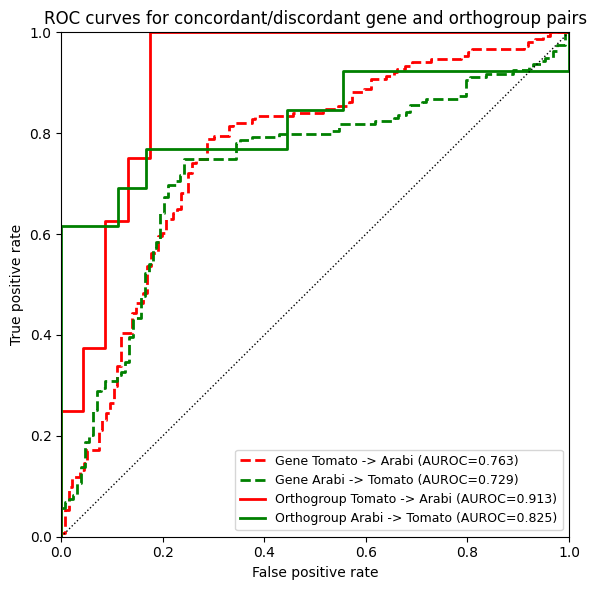

In [71]:
plot_colors = {
    "Tomato -> Arabi": "red",
    "Arabi -> Tomato": "green",
}
plot_linestyles = {
    "Orthogroup": "-",
    "Gene": "--",
}

plt.figure(figsize=(6, 6))
for _, summary_row in bidirectional_auroc_summary.iterrows():
    curve_subset = bidirectional_roc_curves.loc[
        (bidirectional_roc_curves["pair_type"] == summary_row["pair_type"])
        & (
            bidirectional_roc_curves["prediction_direction"]
            == summary_row["prediction_direction"]
        )
    ]
    plt.plot(
        curve_subset["fpr"],
        curve_subset["tpr"],
        color=plot_colors[summary_row["prediction_direction"]],
        linestyle=plot_linestyles[summary_row["pair_type"]],
        linewidth=2,
        label=(
            f"{summary_row['pair_type']} {summary_row['prediction_direction']} "
            f"(AUROC={summary_row['auroc']:.3f})"
        ),
    )

plt.plot([0, 1], [0, 1], color="black", linestyle=":", linewidth=1)
plt.xlim(0, 1)
plt.ylim(0, 1)
plt.xlabel("False positive rate")
plt.ylabel("True positive rate")
plt.title("ROC curves for concordant/discordant gene and orthogroup pairs")
plt.legend(loc="lower right", fontsize=9)
plt.tight_layout()

In [72]:
new_merged_result

,Tomato,Arabi,Classification
0,1.556570,0.829771,Non-substantial
1,-1.243455,-0.225000,Non-substantial
2,-5.534877,-4.223427,Substantial
3,0.275947,-1.414881,Non-substantial
4,0.139494,0.601976,Non-substantial
...,...,...,...
7681,-0.287900,-1.503203,Non-substantial
7682,-2.352309,0.097392,Non-substantial
7683,2.554874,-0.513197,Non-substantial
7684,-0.311219,0.409064,Non-substantial


In [75]:
merged_ortho_df

,Arabidopsis Log2FC,baseMean,Tomato Log2FC,lfcSE,stat,pvalue,padj
Locus,,,,,,,
10950at3193,-0.035878,820.953574,-0.126100,0.192539,-0.654930,5.125128e-01,5.742354e-01
109808at3193,0.929422,140.364526,-0.455828,0.286738,-1.589702,1.119021e-01,1.547758e-01
110108at3193,-0.643508,218.181011,-0.328056,0.190015,-1.726475,8.426192e-02,1.200075e-01
110263at3193,-0.249289,241.984737,0.577213,0.178636,3.231229,1.232592e-03,2.613319e-03
110509at3193,2.383196,132.476352,2.890727,0.605100,4.777275,1.776866e-06,5.965421e-06
...,...,...,...,...,...,...,...
923at3193,0.212197,1489.288291,-0.161708,0.141834,-1.140115,2.542382e-01,3.156876e-01
9592at3193,0.699836,499.026848,-0.268884,0.174269,-1.542929,1.228481e-01,1.673168e-01
9601at3193,-0.204587,1031.260474,-1.231811,0.124719,-9.876713,5.252769e-23,1.002314e-21


In [76]:
merged_gene_df = (
    arabi_genes_trimmed.rename(columns={"log2FoldChange": "Arabidopsis Log2FC"})
    [["arabidopsis Symbol", "Arabidopsis Log2FC"]]
    .merge(
        right=arabi_og[["Symbol", "Orthogroup"]].drop_duplicates(
            subset="Symbol", keep="first"
        ),
        left_on="arabidopsis Symbol",
        right_on="Symbol",
        how="left",
    )
    .drop(columns="Symbol")
    .merge(
        right=tomato_genes_trimmed.rename(
            columns={"log2FoldChange": "Tomato Log2FC"}
        )[["arabidopsis Symbol", "Tomato Log2FC"]],
        on="arabidopsis Symbol",
        how="inner",
    )
    [["Orthogroup", "arabidopsis Symbol", "Arabidopsis Log2FC", "Tomato Log2FC"]]
    .set_index("arabidopsis Symbol")
)

merged_gene_df

,Orthogroup,Arabidopsis Log2FC,Tomato Log2FC
arabidopsis Symbol,,,
AT1G01020,871774at3193,0.829771,1.556570
AT1G01050,867902at3193,-0.225000,-1.243455
AT1G01060,881155at3193,-4.223427,-5.534877
AT1G01090,868495at3193,-1.414881,0.275947
AT1G01100,886628at3193,0.601976,0.139494
...,...,...,...
AT5G67350,889429at3193,-1.503203,-0.287900
AT5G67370,322116at3193,0.097392,-2.352309
AT5G67390,85744at3193,-0.513197,2.554874


In [103]:
gene_threshold = 1.5

merged_gene_df_arabi_threshold = merged_gene_df.loc[
    merged_gene_df["Arabidopsis Log2FC"].abs() > gene_threshold
] .copy()

merged_gene_df_arabi_threshold["Orthogroup Arabidopsis Log2FC"] = merged_gene_df_arabi_threshold[
    "Orthogroup"
] .map(merged_ortho_df["Arabidopsis Log2FC"] )

merged_gene_df_arabi_threshold[
    "Orthogroup exceeds Arabidopsis threshold in same direction"
] = (
    (merged_gene_df_arabi_threshold["Arabidopsis Log2FC"] > gene_threshold)
    & (merged_gene_df_arabi_threshold["Orthogroup Arabidopsis Log2FC"] > gene_threshold)
) | (
    (merged_gene_df_arabi_threshold["Arabidopsis Log2FC"] < -gene_threshold)
    & (merged_gene_df_arabi_threshold["Orthogroup Arabidopsis Log2FC"] < -gene_threshold)
)

merged_gene_df_arabi_threshold

,Orthogroup,Arabidopsis Log2FC,Tomato Log2FC,Orthogroup Arabidopsis Log2FC,Orthogroup exceeds Arabidopsis threshold in same direction
arabidopsis Symbol,,,,,
AT1G01060,881155at3193,-4.223427,-5.534877,NaN,False
AT1G01120,127735at3193,-2.580977,-3.956204,NaN,False
AT1G01300,346708at3193,-2.565529,3.521809,0.388264,False
AT1G01340,755355at3193,-3.127349,0.933164,-0.303010,False
AT1G01560,866982at3193,-5.279548,0.161664,-1.597389,True
...,...,...,...,...,...
AT5G65490,878177at3193,1.875256,0.302095,NaN,False
AT5G66090,126087at3193,2.318622,0.393589,NaN,False
AT5G66850,127629at3193,-1.571900,-1.403495,NaN,False


In [104]:
merged_gene_df_arabi_threshold[
    "Tomato exceeds threshold in same direction"
 ] = (
    (merged_gene_df_arabi_threshold["Arabidopsis Log2FC"] > gene_threshold)
    & (merged_gene_df_arabi_threshold["Tomato Log2FC"] > gene_threshold)
) | (
    (merged_gene_df_arabi_threshold["Arabidopsis Log2FC"] < -gene_threshold)
    & (merged_gene_df_arabi_threshold["Tomato Log2FC"] < -gene_threshold)
)

merged_gene_df_arabi_threshold

,Orthogroup,Arabidopsis Log2FC,Tomato Log2FC,Orthogroup Arabidopsis Log2FC,Orthogroup exceeds Arabidopsis threshold in same direction,Tomato exceeds threshold in same direction
arabidopsis Symbol,,,,,,
AT1G01060,881155at3193,-4.223427,-5.534877,NaN,False,True
AT1G01120,127735at3193,-2.580977,-3.956204,NaN,False,True
AT1G01300,346708at3193,-2.565529,3.521809,0.388264,False,False
AT1G01340,755355at3193,-3.127349,0.933164,-0.303010,False,False
AT1G01560,866982at3193,-5.279548,0.161664,-1.597389,True,False
...,...,...,...,...,...,...
AT5G65490,878177at3193,1.875256,0.302095,NaN,False,False
AT5G66090,126087at3193,2.318622,0.393589,NaN,False,False
AT5G66850,127629at3193,-1.571900,-1.403495,NaN,False,False


In [105]:
fisher_input_df = merged_gene_df_arabi_threshold[[
    "Orthogroup exceeds Arabidopsis threshold in same direction",
    "Tomato exceeds threshold in same direction",
]].copy()

fisher_contingency_table = pd.crosstab(
    fisher_input_df["Orthogroup exceeds Arabidopsis threshold in same direction"],
    fisher_input_df["Tomato exceeds threshold in same direction"],
).reindex(index=[False, True], columns=[False, True], fill_value=0)

fisher_odds_ratio, fisher_p_value = stats.fisher_exact(
    fisher_contingency_table.to_numpy(),
    alternative="greater",
)

fisher_exact_summary = pd.DataFrame(
    {
        "odds_ratio": [fisher_odds_ratio],
        "p_value": [fisher_p_value],
    }
)

fisher_contingency_table, fisher_exact_summary

(Tomato exceeds threshold in same direction          False  True 
 Orthogroup exceeds Arabidopsis threshold in sam...              
 False                                                 541    204
 True                                                   18     11,
    odds_ratio   p_value
 0    1.620643  0.150893)

In [106]:
readable_fisher_table = fisher_contingency_table.rename(
    index={
        False: "Orthogroup below / opposite direction",
        True: "Orthogroup exceeds in same direction",
    },
    columns={
        False: "Tomato below / opposite direction",
        True: "Tomato exceeds in same direction",
    },
)

readable_fisher_table["Row total"] = readable_fisher_table.sum(axis=1)
readable_fisher_table.loc["Column total"] = readable_fisher_table.sum(axis=0)

readable_fisher_table

Tomato exceeds threshold in same direction,Tomato below / opposite direction,Tomato exceeds in same direction,Row total
Orthogroup exceeds Arabidopsis threshold in same direction,,,
Orthogroup below / opposite direction,541,204,745
Orthogroup exceeds in same direction,18,11,29
Column total,559,215,774


In [108]:
fisher_same_vs_opposite_df = merged_gene_df_arabi_threshold[[
    "Orthogroup exceeds Arabidopsis threshold in same direction",
    "Arabidopsis Log2FC",
    "Tomato Log2FC",
]].copy()

fisher_same_vs_opposite_df["Tomato in same direction"] = (
    fisher_same_vs_opposite_df["Arabidopsis Log2FC"]
    * fisher_same_vs_opposite_df["Tomato Log2FC"]
    > 0
)

fisher_same_vs_opposite_table = pd.crosstab(
    fisher_same_vs_opposite_df[
        "Orthogroup exceeds Arabidopsis threshold in same direction"
    ],
    fisher_same_vs_opposite_df["Tomato in same direction"],
).reindex(index=[False, True], columns=[False, True], fill_value=0)

fisher_same_vs_opposite_odds_ratio, fisher_same_vs_opposite_p_value = stats.fisher_exact(
    fisher_same_vs_opposite_table.to_numpy(),
    alternative="greater",
)

fisher_same_vs_opposite_summary = pd.DataFrame(
    {
        "odds_ratio": [fisher_same_vs_opposite_odds_ratio],
        "p_value": [fisher_same_vs_opposite_p_value],
    }
)

readable_fisher_same_vs_opposite_table = fisher_same_vs_opposite_table.rename(
    index={
        False: "Orthogroup below / opposite direction",
        True: "Orthogroup exceeds in same direction",
    },
    columns={
        False: "Tomato in opposite direction",
        True: "Tomato in same direction",
    },
)

readable_fisher_same_vs_opposite_table["Row total"] = (
    readable_fisher_same_vs_opposite_table.sum(axis=1)
)
readable_fisher_same_vs_opposite_table.loc["Column total"] = (
    readable_fisher_same_vs_opposite_table.sum(axis=0)
)

readable_fisher_same_vs_opposite_table, fisher_same_vs_opposite_summary

(Tomato in same direction                            Tomato in opposite direction  \
 Orthogroup exceeds Arabidopsis threshold in sam...                                 
 Orthogroup below / opposite direction                                        274   
 Orthogroup exceeds in same direction                                           8   
 Column total                                                                 282   
 
 Tomato in same direction                            Tomato in same direction  \
 Orthogroup exceeds Arabidopsis threshold in sam...                             
 Orthogroup below / opposite direction                                    471   
 Orthogroup exceeds in same direction                                      21   
 Column total                                                             492   
 
 Tomato in same direction                            Row total  
 Orthogroup exceeds Arabidopsis threshold in sam...             
 Orthogroup below / opposite directi

In [111]:
non_missing_orthogroup_df = merged_gene_df_arabi_threshold.dropna(
    subset=["Orthogroup Arabidopsis Log2FC"]
 ).copy()

non_missing_fisher_input_df = non_missing_orthogroup_df[[
    "Orthogroup exceeds Arabidopsis threshold in same direction",
    "Tomato exceeds threshold in same direction",
]].copy()

non_missing_fisher_contingency_table = pd.crosstab(
    non_missing_fisher_input_df[
        "Orthogroup exceeds Arabidopsis threshold in same direction"
    ],
    non_missing_fisher_input_df["Tomato exceeds threshold in same direction"],
).reindex(index=[False, True], columns=[False, True], fill_value=0)

non_missing_fisher_odds_ratio, non_missing_fisher_p_value = stats.fisher_exact(
    non_missing_fisher_contingency_table.to_numpy(),
    alternative="greater",
)

non_missing_fisher_summary = pd.DataFrame(
    {
        "odds_ratio": [non_missing_fisher_odds_ratio],
        "p_value": [non_missing_fisher_p_value],
        "n_genes": [len(non_missing_orthogroup_df)],
    }
)

readable_non_missing_fisher_table = non_missing_fisher_contingency_table.rename(
    index={
        False: "Orthogroup below / opposite direction",
        True: "Orthogroup exceeds in same direction",
    },
    columns={
        False: "Tomato below / opposite direction",
        True: "Tomato exceeds in same direction",
    },
)

readable_non_missing_fisher_table["Row total"] = readable_non_missing_fisher_table.sum(
    axis=1
)
readable_non_missing_fisher_table.loc["Column total"] = readable_non_missing_fisher_table.sum(
    axis=0
)

display(readable_non_missing_fisher_table)
non_missing_fisher_summary

Tomato exceeds threshold in same direction,Tomato below / opposite direction,Tomato exceeds in same direction,Row total
Orthogroup exceeds Arabidopsis threshold in same direction,,,
Orthogroup below / opposite direction,76,19,95
Orthogroup exceeds in same direction,18,11,29
Column total,94,30,124


,odds_ratio,p_value,n_genes
0,2.444444,0.045231,124


In [110]:
def run_direction_specific_fisher_test(direction_label, gene_mask, orthogroup_mask, tomato_mask):
    direction_df = non_missing_orthogroup_df.loc[gene_mask].copy()
    direction_table = pd.crosstab(
        orthogroup_mask.loc[direction_df.index],
        tomato_mask.loc[direction_df.index],
    ).reindex(index=[False, True], columns=[False, True], fill_value=0)

    direction_odds_ratio, direction_p_value = stats.fisher_exact(
        direction_table.to_numpy(),
        alternative="greater",
    )

    readable_direction_table = direction_table.rename(
        index={
            False: "Orthogroup below threshold",
            True: "Orthogroup exceeds threshold",
        },
        columns={
            False: "Tomato below threshold",
            True: "Tomato exceeds threshold",
        },
    )
    readable_direction_table["Row total"] = readable_direction_table.sum(axis=1)
    readable_direction_table.loc["Column total"] = readable_direction_table.sum(axis=0)

    direction_summary = pd.DataFrame(
        {
            "direction": [direction_label],
            "odds_ratio": [direction_odds_ratio],
            "p_value": [direction_p_value],
            "n_genes": [len(direction_df)],
        }
    )
    return readable_direction_table, direction_summary

positive_gene_mask = non_missing_orthogroup_df["Arabidopsis Log2FC"] > gene_threshold
negative_gene_mask = non_missing_orthogroup_df["Arabidopsis Log2FC"] < -gene_threshold

positive_orthogroup_mask = (
    non_missing_orthogroup_df["Orthogroup Arabidopsis Log2FC"] > gene_threshold
)
negative_orthogroup_mask = (
    non_missing_orthogroup_df["Orthogroup Arabidopsis Log2FC"] < -gene_threshold
)

positive_tomato_mask = non_missing_orthogroup_df["Tomato Log2FC"] > gene_threshold
negative_tomato_mask = non_missing_orthogroup_df["Tomato Log2FC"] < -gene_threshold

positive_direction_fisher_table, positive_direction_fisher_summary = (
    run_direction_specific_fisher_test(
        direction_label="Positive",
        gene_mask=positive_gene_mask,
        orthogroup_mask=positive_orthogroup_mask,
        tomato_mask=positive_tomato_mask,
    )
)

negative_direction_fisher_table, negative_direction_fisher_summary = (
    run_direction_specific_fisher_test(
        direction_label="Negative",
        gene_mask=negative_gene_mask,
        orthogroup_mask=negative_orthogroup_mask,
        tomato_mask=negative_tomato_mask,
    )
)

direction_split_fisher_summary = pd.concat(
    [positive_direction_fisher_summary, negative_direction_fisher_summary],
    ignore_index=True,
 )

positive_direction_fisher_table, negative_direction_fisher_table, direction_split_fisher_summary

(Tomato Log2FC                  Tomato below threshold  \
 Orthogroup Arabidopsis Log2FC                           
 Orthogroup below threshold                         22   
 Orthogroup exceeds threshold                        5   
 Column total                                       27   
 
 Tomato Log2FC                  Tomato exceeds threshold  Row total  
 Orthogroup Arabidopsis Log2FC                                       
 Orthogroup below threshold                            8         30  
 Orthogroup exceeds threshold                          3          8  
 Column total                                         11         38  ,
 Tomato Log2FC                  Tomato below threshold  \
 Orthogroup Arabidopsis Log2FC                           
 Orthogroup below threshold                         54   
 Orthogroup exceeds threshold                       13   
 Column total                                       67   
 
 Tomato Log2FC                  Tomato exceeds threshold  Row tot